In [2]:
import torch
from torch import nn
from torch.nn import BatchNorm1d
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import os
import json
import random
import pkbar
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn as nn
import datetime
import shutil
import time
import numpy as np


from sklearn.preprocessing import MinMaxScaler
from utils.createLoader import createLoaders

In [3]:
### Constants
DATA_PATH = 'data/cmod_clean_200ms.csv';
CONFIG_PATH = "class_TI_columnsdropped.json"

####


pd.set_option("display.max_columns", None);
config = None
### Config
with open(CONFIG_PATH, 'r', encoding = 'utf-8') as file: 
    config = json.load(file)

the shape of datasetX is torch.Size([518788, 40])
the shape of datasetY is torch.Size([518788])


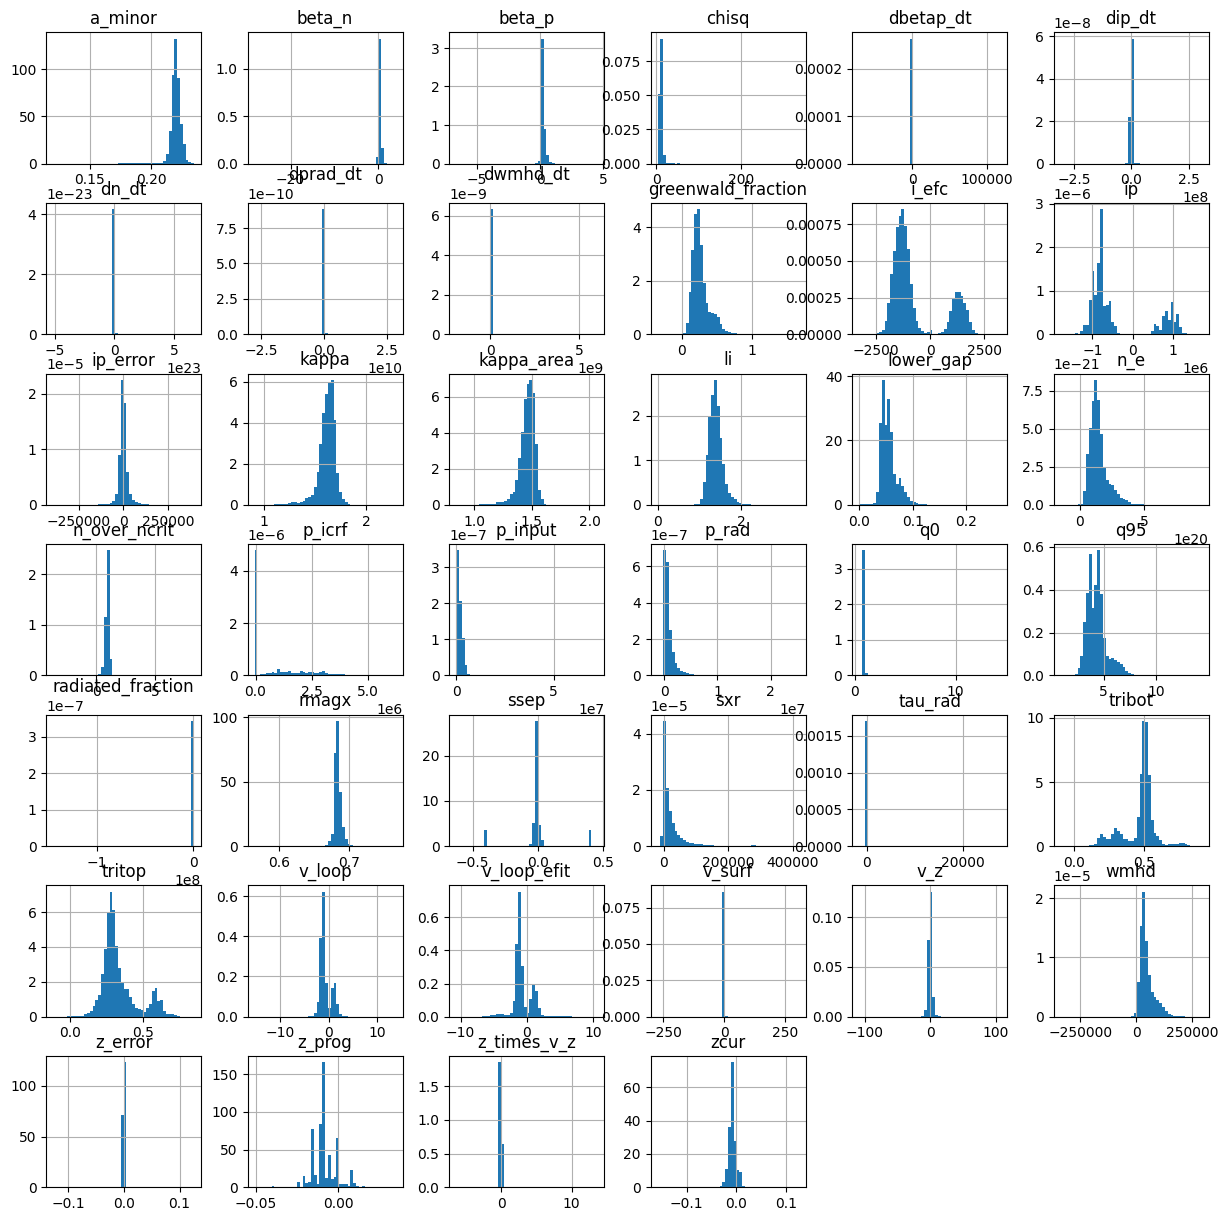

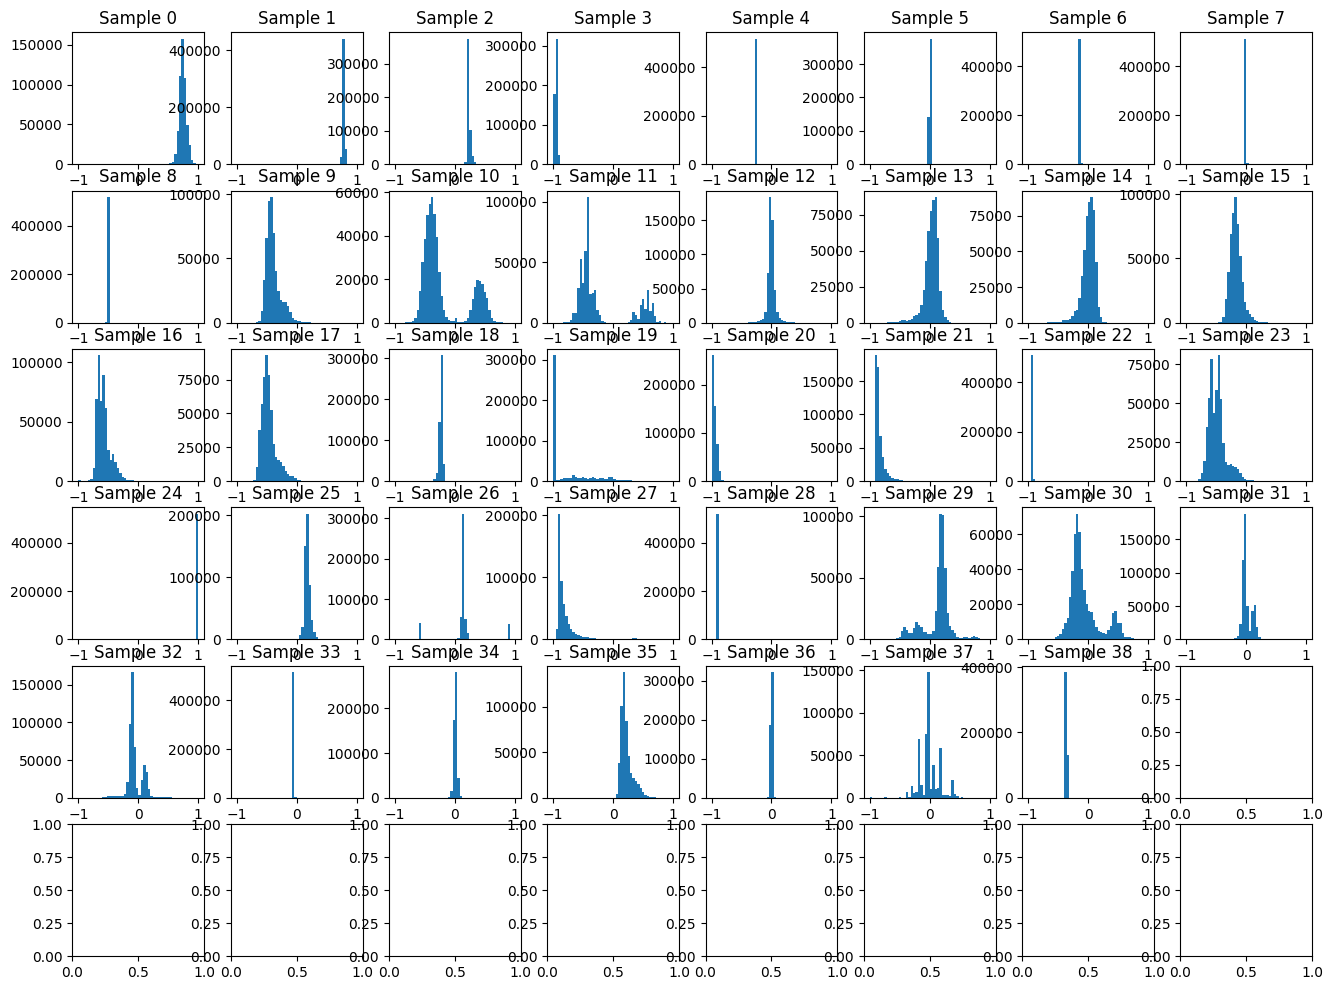

In [4]:
dataset =pd.read_csv(DATA_PATH,sep=',',index_col=None)

train_loader, test_loader, val_loader = createLoaders(config, dataset=dataset)

In [5]:
# X, y = next(iter(class_ti_train))  # grab one batch

# fig, axes = plt.subplots(6, 8, figsize=(16, 12))
# axes = axes.ravel()  # flatten into 1D array

# columns_to_plot = np.arange(2, 40)

# for i in columns_to_plot:
#     data_to_plot = X[:, i].detach().cpu().numpy()
#     axes[i].hist(data_to_plot[i], bins=20)
#     axes[i].set_title(f"Sample {i}")

# print(X[:,].shape)

features to ignore because they're probably useless

```
time
dip_smoothed
dipprog_dt
dli_dt
ip_prog
p_lh
p_oh
qstar
upper_gap
```


In [6]:
class MLP(nn.Module):
    def __init__(self,input_shape,output_shape):
        super(MLP, self).__init__()

        self.init_layer = nn.Linear(input_shape,64)
        self.B0 = nn.BatchNorm1d(64)
        self.L1 = nn.Linear(64,256)
        self.B1 = nn.BatchNorm1d(256)
        self.L2 = nn.Linear(256,512)
        self.B2 = nn.BatchNorm1d(512)
        self.L3 = nn.Linear(512,256)
        self.B3 = nn.BatchNorm1d(256)
        self.L4 = nn.Linear(256,128)
        self.B4 = nn.BatchNorm1d(128)
        self.output = nn.Linear(128,output_shape)
        self.activation = nn.SELU()
    def forward(self,x):

        x = self.activation(self.B0(self.init_layer(x))) # SELU(BNorm(Linear(x)))
        x = self.activation(self.B1(self.L1(x)))
        x = self.activation(self.B2(self.L2(x)))
        x = self.activation(self.B3(self.L3(x)))
        x = self.activation(self.B4(self.L4(x)))
        x = self.output(x) # Return logits; apply sigmoid only for probabilities/evaluation.

        return x

In [7]:
X_sample, y_sample = next(iter(train_loader))  # grab one batch

num_cols = X_sample.shape[1]

classifier = MLP(input_shape = num_cols,output_shape=1) # Singular output
print(classifier)

MLP(
  (init_layer): Linear(in_features=40, out_features=64, bias=True)
  (B0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (L1): Linear(in_features=64, out_features=256, bias=True)
  (B1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (L2): Linear(in_features=256, out_features=512, bias=True)
  (B2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (L3): Linear(in_features=512, out_features=256, bias=True)
  (B3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (L4): Linear(in_features=256, out_features=128, bias=True)
  (B4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (output): Linear(in_features=128, out_features=1, bias=True)
  (activation): SELU()
)


In [8]:
def trainer(config,train_loader,val_loader):
    # Setup random seed
    torch.manual_seed(config['seed'])
    np.random.seed(config['seed'])
    random.seed(config['seed'])
    torch.cuda.manual_seed(config['seed'])

    # Create experiment name
    exp_name = config['name']
    print(exp_name)

    # Create directory structure
    output_folder = config['output']['dir']
    output_path = os.path.join(output_folder,exp_name)
    os.makedirs(output_path,exist_ok=True)

    with open(os.path.join(output_path,'config.json'),'w') as outfile:
        json.dump(config, outfile)


       # Load the dataset
    
    history = {'train_loss':[],'val_loss':[],'lr':[]}


    print("Training Size: {0}".format(len(train_loader.dataset)))
    print("Validation Size: {0}".format(len(val_loader.dataset)))

    # Create the model
    input_shape = num_cols
    output_shape = 1
    net = MLP(input_shape=input_shape,output_shape=output_shape)
    t_params = sum(p.numel() for p in net.parameters())
    print("Network Parameters: ",t_params)
    device = torch.device('cuda')
    net.to('cuda')

    # Optimizer
    num_epochs=int(config['num_epochs'])
    lr = float(config['optimizer']['lr'])

    optimizer = optim.Adam(list(filter(lambda p: p.requires_grad, net.parameters())), lr=lr)
    num_steps = len(train_loader) * num_epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=num_steps, last_epoch=-1,
                                                           eta_min=0)

    startEpoch = 0
    global_step = 0

    print('===========  Optimizer  ==================:')
    print('      LR:', lr)
    print('      num_epochs:', num_epochs)
    print('')


    train_labels = torch.cat([batch_y.reshape(-1).float() for _, batch_y in train_loader])
    num_pos = train_labels.sum()
    num_neg = train_labels.numel() - num_pos
    pos_weight = (num_neg / num_pos).to('cuda')
    print('      positive samples:', int(num_pos.item()))
    print('      negative samples:', int(num_neg.item()))
    print('      pos_weight:', pos_weight.item())

    # Loss Function
    loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for epoch in range(startEpoch,num_epochs):

        kbar = pkbar.Kbar(target=len(train_loader), epoch=epoch, num_epochs=num_epochs, width=20, always_stateful=False)

        net.train()
        running_loss = 0.0

        for i, data in enumerate(train_loader):
            input  = data[0].to('cuda').float()
            y = data[1].to('cuda').float()

            optimizer.zero_grad()

            with torch.set_grad_enabled(True):
                logits = net(input).flatten()

            probabilities = torch.sigmoid(logits)

            loss = loss_function(logits,y)
            train_acc = (torch.sum((probabilities >= 0.5).float() == y)).item() / len(y)

            loss.backward()
            #torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=0.01,error_if_nonfinite=True)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * input.shape[0]
            kbar.update(i, values=[("loss", loss.item()),("train_acc",train_acc)])
            global_step += 1


        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['lr'].append(scheduler.get_last_lr()[0])


        ######################
        ## validation phase ##
        ######################
        if bool(config['run_val']):
            net.eval()
            val_loss = 0.0
            val_acc = 0.0
            with torch.no_grad():
                for i, data in enumerate(val_loader):
                    input  = data[0].to('cuda').float()
                    y = data[1].to('cuda').float()
                    logits = net(input).flatten()
                    
                    probabilities = torch.sigmoid(logits)
                    loss = loss_function(logits,y)

                    val_acc += (torch.sum((probabilities >= 0.5).float() == y)).item() / len(y)
                    val_loss += loss

            val_loss = val_loss.cpu().numpy() / len(val_loader)
            val_acc /= len(val_loader)
            history['val_loss'].append(val_loss)

            kbar.add(1, values=[("val_loss", val_loss.item()),("val_acc",val_acc)])

            name_output_file = config['name']+'_epoch{:02d}_val_loss_{:.6f}.pth'.format(epoch, val_loss)

        else:
            kbar.add(1,values=[('val_loss',0.)])
            name_output_file = config['name']+'_epoch{:02d}_train_loss_{:.6f}.pth'.format(epoch, running_loss / len(train_loader.dataset))

        filename = os.path.join(output_path, name_output_file)

        checkpoint={}
        checkpoint['net_state_dict'] = net.state_dict()
        checkpoint['optimizer'] = optimizer.state_dict()
        checkpoint['scheduler'] = scheduler.state_dict()
        checkpoint['epoch'] = epoch
        checkpoint['history'] = history
        checkpoint['global_step'] = global_step

        torch.save(checkpoint,filename)

        print('')

In [9]:
trainer(config = config,train_loader=train_loader,val_loader=val_loader)

ClassificationModel
Training Size: 363152
Validation Size: 77818
Network Parameters:  317633


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))
print(dicte.keys())

In [ ]:
train_loss = dicte['history']['train_loss']
val_loss = dicte['history']['val_loss']
learning_rate = dicte['history']['lr']

plt.plot(train_loss,'r-',label="Training Loss")
plt.plot(val_loss,'b-',label='Validation Loss')
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel('Loss',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.show()

plt.plot(learning_rate,'k-',label=r"Learning Rate - $\eta$")
plt.legend(fontsize=20)
plt.xlabel('Epoch',fontsize=20)
plt.ylabel(r'$\eta$',fontsize=20)
plt.tick_params(axis='both', labelsize=18)
plt.show()

In [ ]:
input_shape = num_cols
output_shape = config['model']['output_shape']
net = MLP(input_shape=input_shape,output_shape=output_shape)
t_params = sum(p.numel() for p in net.parameters())
print("Network Parameters: ",t_params)
device = torch.device('cuda')
net.to('cuda')

dicte = torch.load(os.path.join(config['name'],os.listdir(config['name'])[-1]))
net.load_state_dict(dicte["net_state_dict"])

In [ ]:
def predict_probabilities(net, loader, device='cuda'):
    net.eval()
    probabilities = []
    y_true = []
    kbar = pkbar.Kbar(target=len(loader), width=20, always_stateful=False)

    with torch.no_grad():
        for i, data in enumerate(loader):
            x = data[0].to(device).float()
            y_true.append(data[1].numpy())

            logits = net(x).flatten()
            y_prob = torch.sigmoid(logits).detach().cpu().numpy()
            probabilities.append(y_prob)

            kbar.update(i)

    return np.concatenate(probabilities), np.concatenate(y_true)

val_predictions, y_val_true = predict_probabilities(net, val_loader)
test_predictions, y_true = predict_probabilities(net, test_loader)

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_curve, roc_auc_score

# Compute the ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_true, test_predictions)

# Calculate ranking metrics. PR-AUC is especially useful with imbalanced disruption labels.
roc_auc = roc_auc_score(y_true, test_predictions)
pr_auc = average_precision_score(y_true, test_predictions)
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot the precision-recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, test_predictions)
plt.figure()
plt.plot(recall_curve, precision_curve, color='green', label=f'PR curve (AP = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

# Tune the threshold on validation data. F2 weights recall more than precision.
val_precision, val_recall, val_thresholds = precision_recall_curve(y_val_true, val_predictions)
beta = 2
val_f2 = (1 + beta**2) * val_precision[:-1] * val_recall[:-1] / ((beta**2 * val_precision[:-1]) + val_recall[:-1] + 1e-12)
best_idx = np.argmax(val_f2)
best_threshold = val_thresholds[best_idx]

test_pred_default = (test_predictions >= 0.5).astype(int)
test_pred_tuned = (test_predictions >= best_threshold).astype(int)

print(f"Best validation threshold by F2: {best_threshold:.4f}")
print(f"Validation F2 at threshold: {val_f2[best_idx]:.4f}")
print(f"Test recall at 0.50 threshold: {recall_score(y_true, test_pred_default):.4f}")
print(f"Test recall at tuned threshold: {recall_score(y_true, test_pred_tuned):.4f}")

cm = confusion_matrix(y_true, test_pred_tuned)
print("Confusion Matrix at tuned threshold:\n", cm)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(classification_report(y_true,test_pred_tuned))

# Disruption-aware metrics at the validation-tuned threshold.
tn, fp, fn, tp = cm.ravel()
precision = precision_score(y_true, test_pred_tuned)
recall = recall_score(y_true, test_pred_tuned)
f1 = f1_score(y_true, test_pred_tuned)
f2 = fbeta_score(y_true, test_pred_tuned, beta=2)
specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)
balanced_accuracy = 0.5 * (recall + specificity)
prevalence = y_true.mean()

print(f"Disruption prevalence: {prevalence:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall / disruption catch rate: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"F2 Score: {f2:.4f}")
print(f"Specificity / stable catch rate: {specificity:.4f}")
print(f"False positive rate: {false_positive_rate:.4f}")
print(f"False negative rate / missed disruption rate: {false_negative_rate:.4f}")
print(f"Balanced accuracy: {balanced_accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")